# Reinforcement Learning Model Analysis 

In [58]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

file_name = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/feudal_MsPacman-v5'
with open(file_name, 'r') as f:
    data = json.load(f)
    
print(data)



{'0': 2270.0, '1': 1540.0, '2': 1540.0, '3': 1060.0, '4': 1670.0, '5': 1250.0, '6': 850.0, '7': 1900.0, '8': 2210.0, '9': 2090.0, '10': 1440.0, '11': 1640.0, '12': 1690.0, '13': 1800.0, '14': 1440.0, '15': 1190.0, '16': 1520.0, '17': 1790.0, '18': 1590.0, '19': 1200.0, '20': 850.0, '21': 850.0, '22': 1310.0, '23': 2390.0, '24': 1060.0, '25': 1360.0, '26': 2720.0, '27': 1580.0, '28': 1570.0, '29': 1840.0, '30': 1340.0, '31': 1090.0, '32': 970.0, '33': 1840.0, '34': 1640.0, '35': 1380.0, '36': 1350.0, '37': 1290.0, '38': 1400.0, '39': 1450.0, '40': 2350.0, '41': 1370.0, '42': 2090.0, '43': 1580.0, '44': 1580.0, '45': 1680.0, '46': 1370.0, '47': 1770.0, '48': 2100.0, '49': 1250.0, '50': 1300.0, '51': 2230.0, '52': 1500.0, '53': 1690.0, '54': 1340.0, '55': 1640.0, '56': 1120.0, '57': 1430.0, '58': 1090.0, '59': 1250.0, '60': 1640.0, '61': 1360.0, '62': 2090.0, '63': 1640.0, '64': 850.0, '65': 1640.0, '66': 1440.0, '67': 1250.0, '68': 1090.0, '69': 1540.0, '70': 1090.0, '71': 1750.0, '72': 

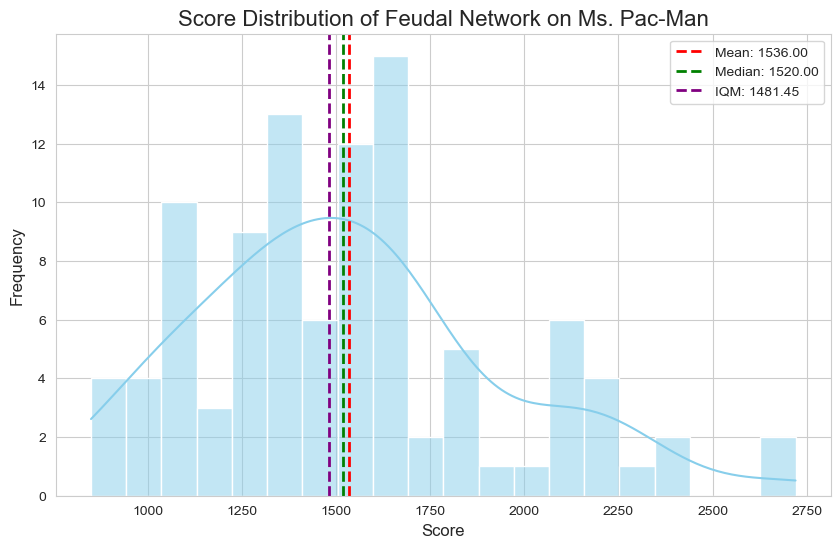

In [59]:

df = pd.DataFrame(list(data.items()), columns=['game', 'score'])
df['score'] = pd.to_numeric(df['score'])
mean_score = df['score'].mean()
median_score = df['score'].median()

# Calculate IQM
q1 = df['score'].quantile(0.25)
q3 = df['score'].quantile(0.75)
iqm_score = df[(df['score'] >= q1) & (df['score'] <= q3)]['score'].mean()
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Plot the histogram of scores with a KDE line
sns.histplot(df['score'], bins=20, kde=True, color='skyblue')

# Add vertical lines for the mean, median, and IQM
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.2f}')
plt.axvline(iqm_score, color='purple', linestyle='dashed', linewidth=2, label=f'IQM: {iqm_score:.2f}')
plt.title('Score Distribution of Feudal Network on Ms. Pac-Man', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

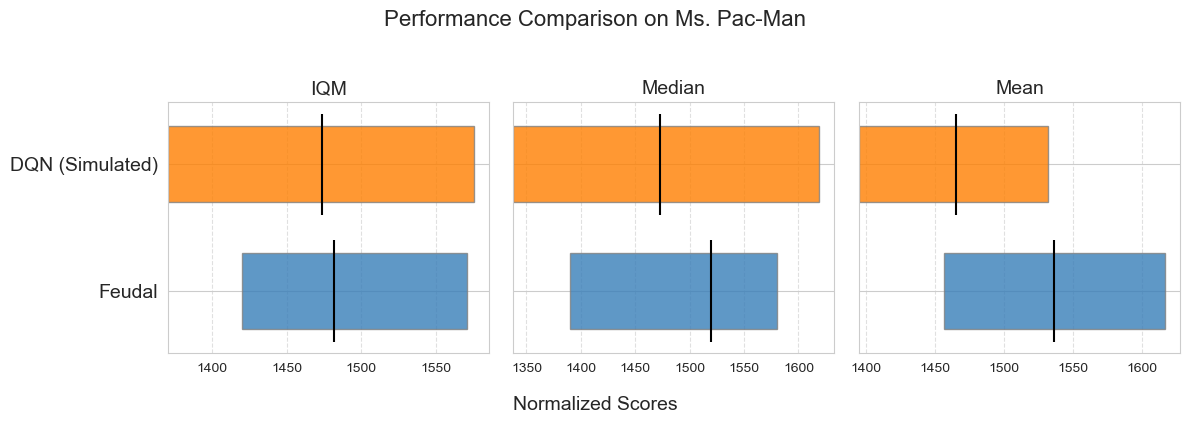

In [65]:
np.random.seed(42)
dqn_data_list = np.random.randint(850, 2000, size=100)
dqn_data_list[np.random.randint(0, 100, 3)] = 2000 # Add some outliers

# Prepare data arrays for analysis
feudal_scores = np.array(list(data.values()))
dqn_scores = np.array(dqn_data_list, dtype=float)

scores_dict = {
    'Feudal': feudal_scores,
    'DQN (Simulated)': dqn_scores
}
algorithms = list(scores_dict.keys())


def calculate_iqm(data):
    """Calculates the Interquartile Mean (IQM)."""
    q1, q3 = np.percentile(data, [25, 75])
    trimmed_data = data[(data >= q1) & (data <= q3)]
    return np.mean(trimmed_data)

def bootstrap_ci(data, metric_func, n_bootstrap=5000, ci_level=0.95):
    """Calculates the confidence interval for a given metric using bootstrapping."""
    bootstrap_metrics = [metric_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    point_estimate = metric_func(data)
    alpha = (1 - ci_level) / 2
    lower_bound = np.percentile(bootstrap_metrics, 100 * alpha)
    upper_bound = np.percentile(bootstrap_metrics, 100 * (1 - alpha))
    return point_estimate, lower_bound, upper_bound

metric_functions = [calculate_iqm, np.median, np.mean]
metric_names = ['IQM', 'Median', 'Mean']


# Plotting with plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
colors = {'Feudal': '#377eb8', 'DQN (Simulated)': '#ff7f00'}

for ax, metric_func, name in zip(axes, metric_functions, metric_names):
    ax.set_title(name, fontsize=14)
    for i, algo in enumerate(algorithms):
        scores = scores_dict[algo]
        point_est, lower, upper = bootstrap_ci(scores, metric_func)
        
        ax.barh(y=i, width=(upper - lower), left=lower, height=0.6,
                color=colors[algo], alpha=0.8, edgecolor='grey')
        
        ax.vlines(x=point_est, ymin=i - 0.4, ymax=i + 0.4,
                  color='black', linewidth=1.5)
        
        ax.grid(axis='x', linestyle='--', alpha=0.6)

axes[0].set_yticks(range(len(algorithms)))
axes[0].set_yticklabels(algorithms, fontsize=14)
# ADD a figure-wide x-label at the bottom
fig.text(0.5, 0.05, 'Normalized Scores', ha='center', fontsize=14)

fig.suptitle("Performance Comparison on Ms. Pac-Man", fontsize=16, x=0.5, y=1.05)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

/var/folders/nh/2c0hnztd0dj_qzwxqc4ngt7h0000gn/T/ipykernel_44250/870805115.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


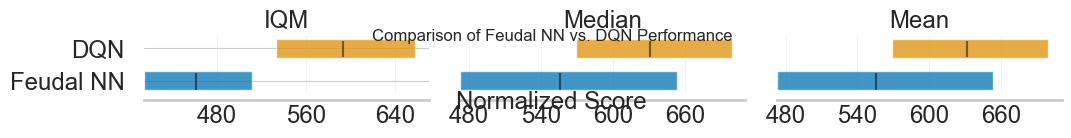

In [49]:
# Simulate DQN data for comparison, not real data
np.random.seed(42)
dqn_data_list = np.random.randint(200, 1000, size=100)
dqn_data_list[np.random.randint(0, 100, 3)] = 2000 # Add some outliers
dqn_data = {str(i): float(v) for i, v in enumerate(dqn_data_list)}

# Reshape Data for rliable 
# Shape must be (number_of_runs, number_of_tasks)
feudal_nn_scores = np.array(list(data.values())).reshape(100, 1)
dqn_scores = np.array(list(dqn_data.values())).reshape(100, 1)

scores_dict = {
    'Feudal NN': feudal_nn_scores,
    'DQN': dqn_scores
}
algorithms = list(scores_dict.keys())

# Define metrics(IQM, Median, and Mean)
aggregate_func = lambda x: np.array([
    metrics.aggregate_iqm(x),
    metrics.aggregate_median(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)
])
metric_names = ['IQM', 'Median', 'Mean']
aggregate_scores, aggregate_cis = rly.get_interval_estimates(
    scores_dict,
    aggregate_func,
    reps=50000)


fig, axes = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_cis,
    metric_names=metric_names,
    algorithms=algorithms)
    

axes[1].xaxis.labelpad = 20

plt.suptitle("Comparison of Feudal NN vs. DQN Performance", x=0.4, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()